In [30]:
from ultralytics import YOLO
import os
import shutil
import random
import yaml
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import kagglehub

In [31]:
base_dir = "/Users/iivaniv/Documents/drone2/drone_dataset_yolo/dataset_txt"
images = [f for f in os.listdir(base_dir) if f.endswith(".jpg")]

train_split = 0.75
val_split = 0.15
test_split = 0.1

random.shuffle(images)
n = len(images)
train_imgs = images[:int(n*train_split)]
val_imgs = images[int(n*train_split):int(n*(train_split+val_split))]
test_imgs = images[int(n*(train_split+val_split)):]

def copy_pairs(img_list, dest_folder):
    for img in img_list:
        label = img.replace(".jpg", ".txt")
        shutil.copy(os.path.join(base_dir, img), os.path.join(f"dataset/images/{dest_folder}", img))
        if os.path.exists(os.path.join(base_dir, label)):
            shutil.copy(os.path.join(base_dir, label), os.path.join(f"dataset/labels/{dest_folder}", label))

for split in ["train", "val", "test"]:
    os.makedirs(f"dataset/images/{split}", exist_ok=True)
    os.makedirs(f"dataset/labels/{split}", exist_ok=True)

copy_pairs(train_imgs, "train")
copy_pairs(val_imgs, "val")
copy_pairs(test_imgs, "test")

print("Everything is going as espected!")

Everything is going as espected!


In [32]:
for root, dirs, files in os.walk("dataset"):
    print(root, len(files), "files")

dataset 0 files
dataset/images 0 files
dataset/images/test 258 files
dataset/images/train 2294 files
dataset/images/val 389 files
dataset/labels 2 files
dataset/labels/test 258 files
dataset/labels/train 2294 files
dataset/labels/val 389 files


In [33]:
import yaml

data = {
    'train': 'dataset/images/train',
    'val': 'dataset/images/val',
    'test': 'dataset/images/test',
    'nc': 1,
    'names': ['drone']
}

with open('data.yaml', 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print("File data.yaml created!")

File data.yaml created!


In [34]:
img_dir = "dataset/images/train"
label_dir = "dataset/labels/train"

augmentor = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.5),
    A.RandomGamma(p=0.3),
    A.Rotate(limit=15, p=0.4, border_mode=cv2.BORDER_REFLECT_101),
    A.Blur(blur_limit=3, p=0.2),
    A.HueSaturationValue(p=0.3)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

num_aug = 1 

def clip_boxes(bboxes):
    clipped = []
    for box in bboxes:
        x, y, w, h = [max(0, min(1, v)) for v in box]
        clipped.append([x, y, w, h])
    return clipped

for img_name in os.listdir(img_dir):
    if not img_name.endswith(".jpg"):
        continue

    img_path = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    image = cv2.imread(img_path)
    if image is None or not os.path.exists(label_path):
        continue

    with open(label_path) as f:
        boxes, classes = [], []
        for line in f.readlines():
            vals = line.strip().split()
            if len(vals) != 5:
                continue
            cls, x, y, bw, bh = map(float, vals)
            boxes.append([x, y, bw, bh])
            classes.append(int(cls))

    for i in range(num_aug):
        try:
            augmented = augmentor(image=image, bboxes=boxes, class_labels=classes)
        except ValueError:
            continue

        aug_img = augmented["image"]
        aug_boxes = clip_boxes(augmented["bboxes"])
        aug_classes = augmented["class_labels"]

        new_name = img_name.replace(".jpg", f"_aug{i}.jpg")
        cv2.imwrite(os.path.join(img_dir, new_name), aug_img)

        with open(os.path.join(label_dir, new_name.replace(".jpg", ".txt")), "w") as f:
            for cls, (x, y, bw, bh) in zip(aug_classes, aug_boxes):
                f.write(f"{cls} {x:.6f} {y:.6f} {bw:.6f} {bh:.6f}\n")

print("✅ Augmentation completed successfully!")

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


✅ Augmentation completed successfully!


In [20]:
splits = ["train", "val", "test"]
for split in splits:
    n_imgs = len([f for f in os.listdir(f"dataset/images/{split}") if f.endswith(".jpg")])
    n_labels = len([f for f in os.listdir(f"dataset/labels/{split}") if f.endswith(".txt")])
    print(f"{split}: {n_imgs} immagini, {n_labels} label")

train: 2031 immagini, 2031 label
val: 204 immagini, 204 label
test: 136 immagini, 136 label


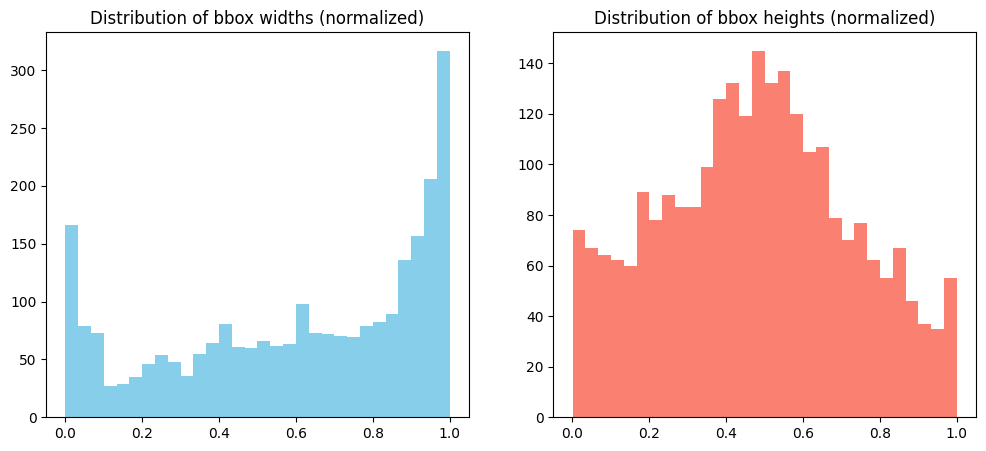

In [21]:
widths, heights = [], []

for label_file in os.listdir("dataset/labels/train"):
    if not label_file.endswith(".txt"):
        continue
    with open(os.path.join("dataset/labels/train", label_file)) as f:
        for line in f:
            cls, x, y, w, h = map(float, line.strip().split())
            widths.append(w)
            heights.append(h)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(widths, bins=30, color='skyblue')
plt.title("Distribution of bbox widths (normalized)")

plt.subplot(1,2,2)
plt.hist(heights, bins=30, color='salmon')
plt.title("Distribution of bbox heights (normalized)")

plt.show()


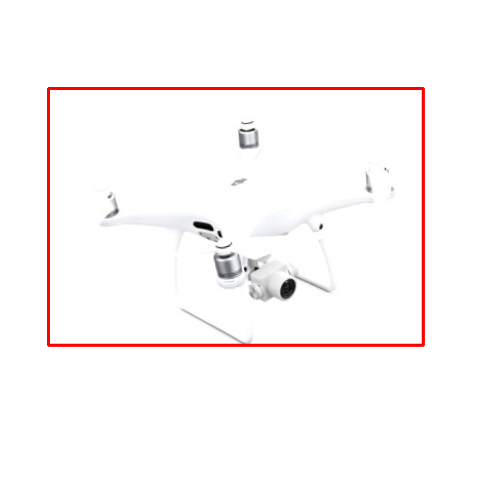

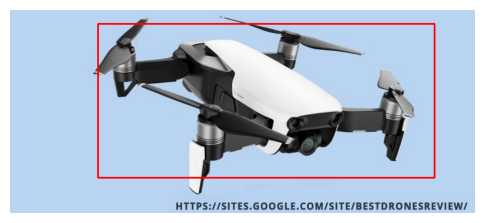

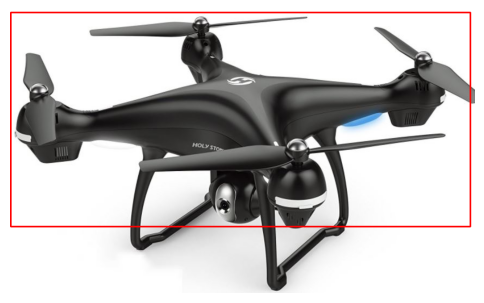

In [22]:
def show_image_with_bbox(split="train"):
    img_file = random.choice(os.listdir(f"dataset/images/{split}"))
    if not img_file.endswith(".jpg"):
        return
    img_path = f"dataset/images/{split}/{img_file}"
    label_path = f"dataset/labels/{split}/{img_file.replace('.jpg','.txt')}"

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with open(label_path) as f:
        for line in f:
            cls, x, y, w, h = map(float, line.strip().split())
            h_img, w_img, _ = img.shape
            x1 = int((x - w/2) * w_img)
            y1 = int((y - h/2) * h_img)
            x2 = int((x + w/2) * w_img)
            y2 = int((y + h/2) * h_img)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_image_with_bbox("train")
show_image_with_bbox("train")
show_image_with_bbox("train")

In [41]:
import torch
torch.cuda.is_available()

model = YOLO('yolov8n.pt')

model.train(
    data='data.yaml',
    epochs=70,
    batch=16,
    imgsz=512,
    augment=True,
    project='drone_detection',
    name='yolov8_drone',
    exist_ok=True,
    save=True,
    save_period=5,
    patience=8,
    optimizer='AdamW',
    lr0=0.0005,
    lrf=0.1,
    momentum=0.9,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    cache='ram',
    device='mps',
    workers=8,
    deterministic=True,
    val=True,
    plots=True,
    amp=True,
    multi_scale=False,
    close_mosaic=10
)


Ultralytics 8.3.226 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M1 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=False, name=yolov8_drone, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=8, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False,

libpng warning: iCCP: known incorrect sRGB profile


train: Caching images (1.1GB RAM): 63% ━━━━━━━╸──── 2186/3489 1.9Kit/s 1.9s<0.7s

libpng warning: iCCP: known incorrect sRGB profile


train: Caching images (1.6GB RAM): 88% ━━━━━━━━━━╸─ 3067/3489 1.6Kit/s 2.4s<0.3s

libpng warning: iCCP: known incorrect sRGB profile


train: Caching images (1.8GB RAM): 100% ━━━━━━━━━━━━ 3489/3489 1.2Kit/s 3.0ss<0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 773.2±961.3 MB/s, size: 798.7 KB)
val: Scanning /Users/iivaniv/ComputerVision/diploma/dataset/labels/val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389 1.7Mit/s 0.0s0s
val: /Users/iivaniv/ComputerVision/diploma/dataset/images/val/pic_722.jpg: corrupt JPEG restored and saved
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
val: Caching images (0.2GB RAM): 100% ━━━━━━━━━━━━ 389/389 827.2it/s 0.5s0.6s
Plotting labels to /Users/iivaniv/ComputerVision/diploma/drone_detection/yolov8_drone/labels.jpg... 


libpng warning: iCCP: known incorrect sRGB profile


optimizer: AdamW(lr=0.0005, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 512 train, 512 val
Using 0 dataloader workers
Logging results to /Users/iivaniv/ComputerVision/diploma/drone_detection/yolov8_drone
Starting training for 70 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/70      5.64G      1.541     -3.878      1.532          4        512: 100% ━━━━━━━━━━━━ 219/219 1.2it/s 2:55<0.9s
WARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 8% ╸─────────── 1/13 0.0it/s 8.2s<5:29WARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 15% ━╸────────── 2/13 0.1it/s 15.5s<2:45WARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 23% ━━╸────────

RuntimeError: Trying to create tensor with negative dimension -1: [1, -1, 5]

In [37]:
csv_path = "drone_detection/yolov8_drone/results.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    table = df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                'metrics/precision(B)', 'metrics/recall(B)',
                'metrics/mAP50(B)', 'metrics/mAP50-95(B)']]

    table = table.groupby('epoch', as_index=False).mean()
    display(table)
else:
    print("results.csv not found. Make sure training is finished and path is correct.")

,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,1.55673,-3.27568,1.67627,0.60532,0.05800,0.05414,0.03117
1,2,1.54978,-6.88732,1.65825,0.67946,0.06032,0.05458,0.02941
